In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

# Info about our initial catalogue source

In [2]:
catalog_4fgl['4FGL J1908.6+0915e']

/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:218: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_BAY", d["ASSOC_PROB_BAY"])
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:219: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_LR", d["ASSOC_PROB_LR"])


# Set up of the analysis

In [3]:
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/fermi_config_sgr1900_15deg_PSF1-3_two_sources_GAL.yaml', logging={'verbosity': 3})

2025-06-03 13:07:28 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [4]:
gta.setup()

2025-06-03 13:07:28 INFO    GTAnalysis.setup(): Running setup.
2025-06-03 13:07:28 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 60774.984781 from DATE-END'. [astropy.wcs.wcs]
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-06-03 13:07:28 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-06-03 13:07:28 INFO    GTBinnedAnalysis.setup(): Running setup for component 01
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-06-03 13:07:28 INFO    GTBinnedAnalysis._create_expcube(): Skipping g

In [5]:
gta.print_model()

2025-06-03 13:07:39 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.276  1.06e-05   2.20       nan      1167.3     
4FGL J1910.2+0904c     0.430   0.394  9.75e-06   2.29       nan      1228.0     
4FGL J1911.0+0905      0.619   0.756  5.61e-05   2.21       nan      8143.1     
4FGL J1911.8+0903c     0.808   0.372  3.75e-06   2.15       nan       378.4     
4FGL J1912.0+0927      0.869   0.320  3.88e-06   2.95       nan       901.1     
4FGL J1908.7+0812      1.056   1.845  6.41e-06   3.36       nan      1649.4     
4FGL J1913.3+0905      1.183   0.902  7.57e-06   3.19       nan      1618.8     
4FGL J1912.7+0957      1.226   0.500  5.24e-06   3.04       nan      1253.7     
4FGL J1911.7+1014c     1.241   0.441   2.7e-06   3.19       nan       673.3     
4FGL J1913.3+1019      1.586   0.331  7.29e-06   2.17 

2025-05-14 17:35:29 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/initial_00.xml...
2025-05-14 17:35:29 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/initial_01.xml...
2025-05-14 17:35:29 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/initial_02.xml...
2025-05-14 17:35:29 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/initial.fits...
2025-05-14 17:35:32 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-14 17:35:32 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 01.
2025-05-14 17:35:33 INFO    GTBinnedAnalysis.writ

<Figure size 2000x2000 with 0 Axes>

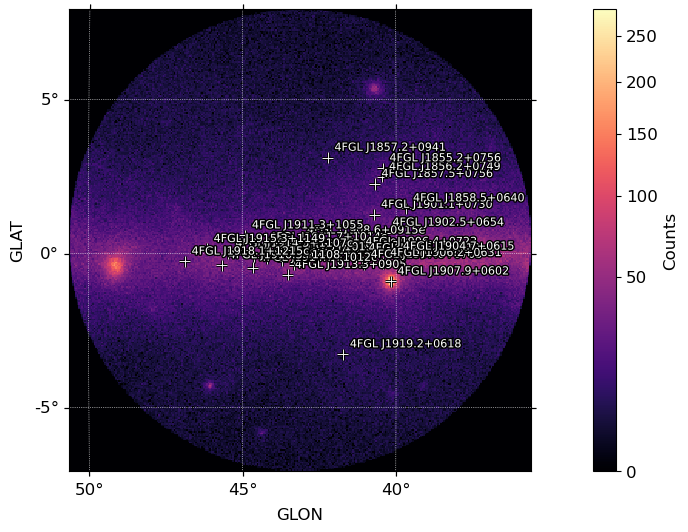

In [6]:
plt.figure(figsize=(20, 20))
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

## Free parameters of the sources in the region 3 degrees around the source

In [7]:
gta.free_sources(free=False)
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)

2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.0+0905     : ['norm', 'alpha', 'beta']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.8+0903c    : ['Prefactor', 'Index']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.0+0927     : ['norm', 'alpha', 'beta']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.7+0812     : ['norm', 'alpha', 'beta']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1913.3+0905     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-05-14 17:35:41 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.7+0957     : ['norm'

In [8]:
gta.optimize()
gta.fit()

2025-05-14 17:35:41 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602', 'isodiff']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 6877944.254
Fitting shape 4FGL J1907.9+0602 TS:  28182.362
Fitting shape 4FGL J1911.0+0905 TS:   7195.275
Fitting shape 4FGL J1906.4+0723 TS:   1932.634
Drm_Cache::update Measured counts < 0 4FGL J1906.4+0723 21 -8.22355e-13 3.93421e-13
32682.7 11833.4 4092.41 1365.8 437.28 136.169 41.8309 12.4857 3.54099 0.945573 0.233141 0.0540704 0.0116039 0.00217352 0.000345277 4.55659e-05 4.80954e-06 3.91807e-07 2.3406e-08 9.72343e-10 2.57612e-11 3.93421e-13 
Fitting shape 4FGL J1906.9+0712 TS:    861.207
Fitting shape 4FGL J1913.3+0905 TS:    479.496
Fitting shape 4FGL J1908.7+0812 TS:    316.061
Fitting shape 4FGL J1915.3+1149 TS:    248.398
Fitting shape 4FGL J1901.1+0730 TS:    244.061
Fitting shape 4FGL J1902.5+0654 TS:    234.211
Fitting shape 4FGL J1910.2+0904c TS:    226.078
Fitting shape 4FGL J1916.3+1108 TS:    212.413
Fitting shape 4FGL J1912.7+0957 TS:    203.870
Fitting shape 4FGL J1913.3+1019 TS:    178.635
Fitting shape 4FGL J1918.1+1215c TS:    163.040
Fit

2025-05-14 17:36:44 INFO    GTAnalysis.optimize(): Finished
2025-05-14 17:36:44 INFO    GTAnalysis.optimize(): LogLike: -1003422.345267 Delta-LogLike: 4580.596295
2025-05-14 17:36:44 INFO    GTAnalysis.optimize(): Execution time: 63.15 s
2025-05-14 17:36:44 INFO    GTAnalysis.fit(): Starting fit.
2025-05-14 17:38:45 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-05-14 17:38:45 INFO    GTAnalysis.fit(): LogLike: -1003415.703 DeltaLogLike:        6.643 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 6.6425795630784705,
 'edm': 0.00045815125918933055,
 'loglike': -1003415.702687121,
 'covariance': array([[ 1.29505134e-03,  1.11343582e-04,  1.42300782e-04, ...,
         -3.14458704e-08,  1.50871704e-08, -2.76290392e-12],
        [ 1.11343582e-04,  1.16060942e-03,  1.31498195e-05, ...,
          4.54378145e-09, -6.58408593e-09,  4.83344074e-13],
        [ 1.42300782e-04,  1.31498195e-05,  1.63141216e-03, ...,
          4.68246282e-09, -9.76947891e-09,  6.32290474e-13],
        ...,
        [-3.14458704e-08,  4.54378145e-09,  4.68246282e-09, ...,
          7.27321678e-08,  3.47901468e-09, -2.56370135e-13],
        [ 1.50871704e-08, -6.58408593e-09, -9.76947891e-09, ...,
          3.47901468e-09,  9.23721926e-08,  3.04070105e-13],
        [-2.76290392e-12,  4.83344074e-13,  6.32290474e-13, ...,
         -2.56370135e-13,  3.04070105e-13,  5.83823618e-14]]),
 'correlation': array([[ 1.00000000e+00,  9.08194045e-02,

In [6]:
gta.print_model()

2025-06-03 13:07:39 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.276  1.06e-05   2.20       nan      1167.3     
4FGL J1910.2+0904c     0.430   0.394  9.75e-06   2.29       nan      1228.0     
4FGL J1911.0+0905      0.619   0.756  5.61e-05   2.21       nan      8143.1     
4FGL J1911.8+0903c     0.808   0.372  3.75e-06   2.15       nan       378.4     
4FGL J1912.0+0927      0.869   0.320  3.88e-06   2.95       nan       901.1     
4FGL J1908.7+0812      1.056   1.845  6.41e-06   3.36       nan      1649.4     
4FGL J1913.3+0905      1.183   0.902  7.57e-06   3.19       nan      1618.8     
4FGL J1912.7+0957      1.226   0.500  5.24e-06   3.04       nan      1253.7     
4FGL J1911.7+1014c     1.241   0.441   2.7e-06   3.19       nan       673.3     
4FGL J1913.3+1019      1.586   0.331  7.29e-06   2.17 

In [11]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-05-14 18:01:25 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-14 18:01:30 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-14 18:03:27 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-14 18:03:29 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-14 18:03:29 INFO    GTAnalysis.tsmap(): Execution time: 123.97 s


<Figure size 640x480 with 0 Axes>

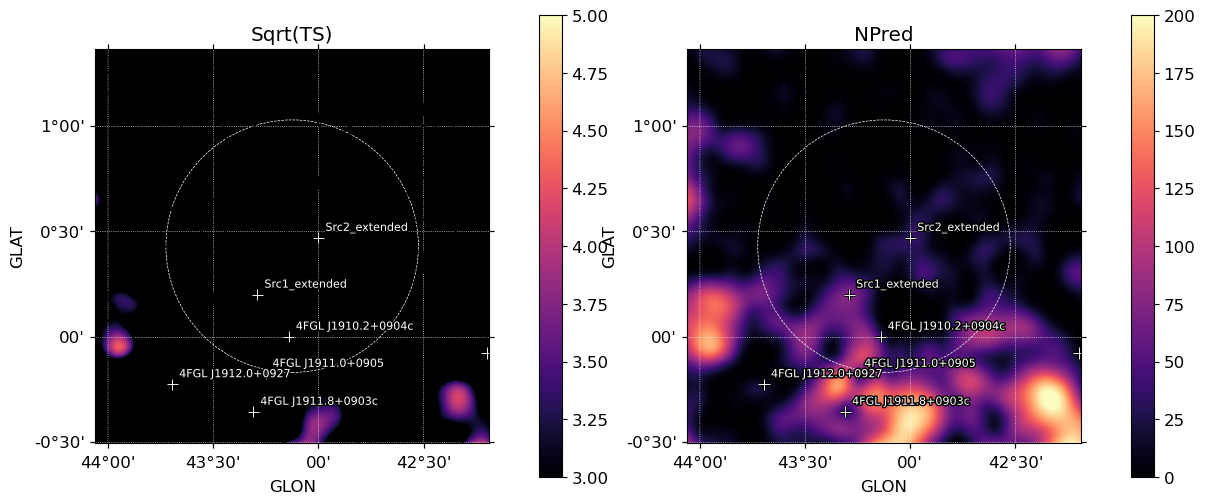

In [107]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=3,vmax=5,subplot=121,cmap='magma', zoom = 8)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 8)
plt.gca().set_title('NPred')
plt.show()

In [14]:
plt.clf()
plt.clf()
tsmap_postfit_no_source = gta.tsmap(
    prefix='TSmap_no_source',
    make_plots=True,
    write_fits=True,
    write_npy=True, 
    exclude=gta.roi.sources[0].name)

2025-05-14 18:04:32 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-14 18:04:36 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-14 18:06:20 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-14 18:06:23 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/TSmap_no_source_pointsource_powerlaw_2.00_tsmap.npy
2025-05-14 18:06:23 INFO    GTAnalysis.tsmap(): Execution time: 110.73 s


<Figure size 640x480 with 0 Axes>

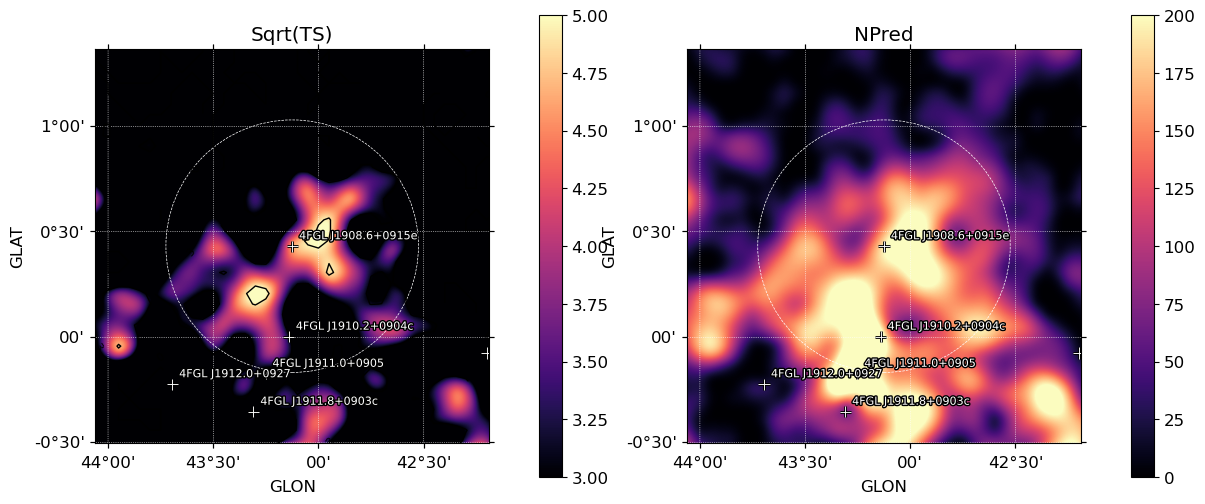

In [15]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit_no_source['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=3,vmax=5,subplot=121,cmap='magma', zoom = 8)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit_no_source['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 8)
plt.gca().set_title('NPred')
plt.show()

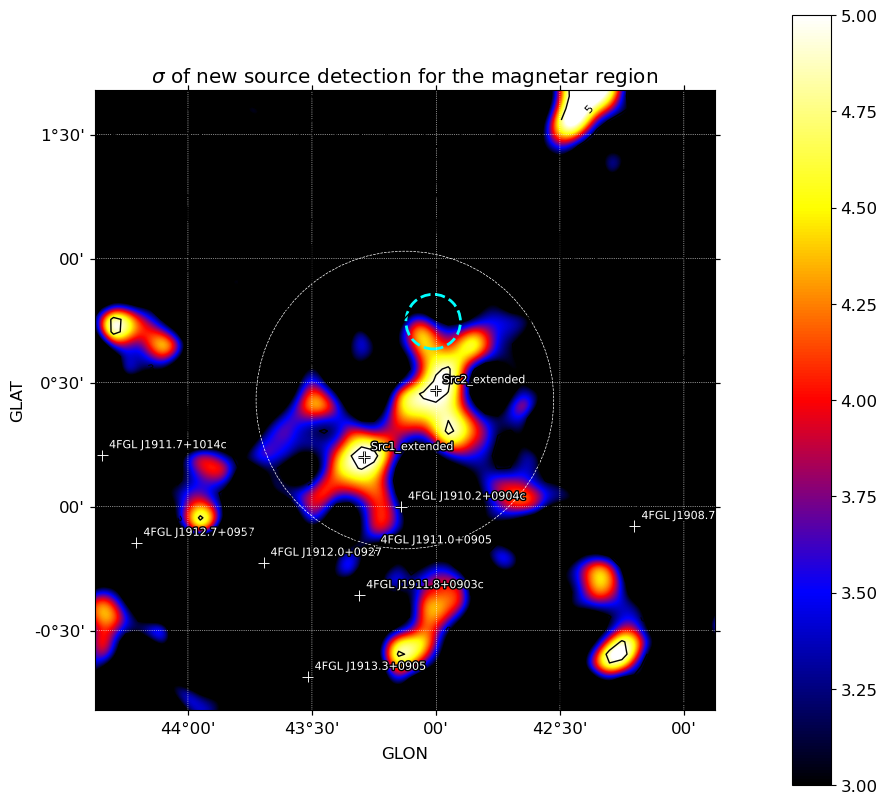

In [ ]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(8, 8))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=3,vmax=5, levels=[0,3,5,7])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sigma$ of new source detection for the magnetar region")
plt.show()

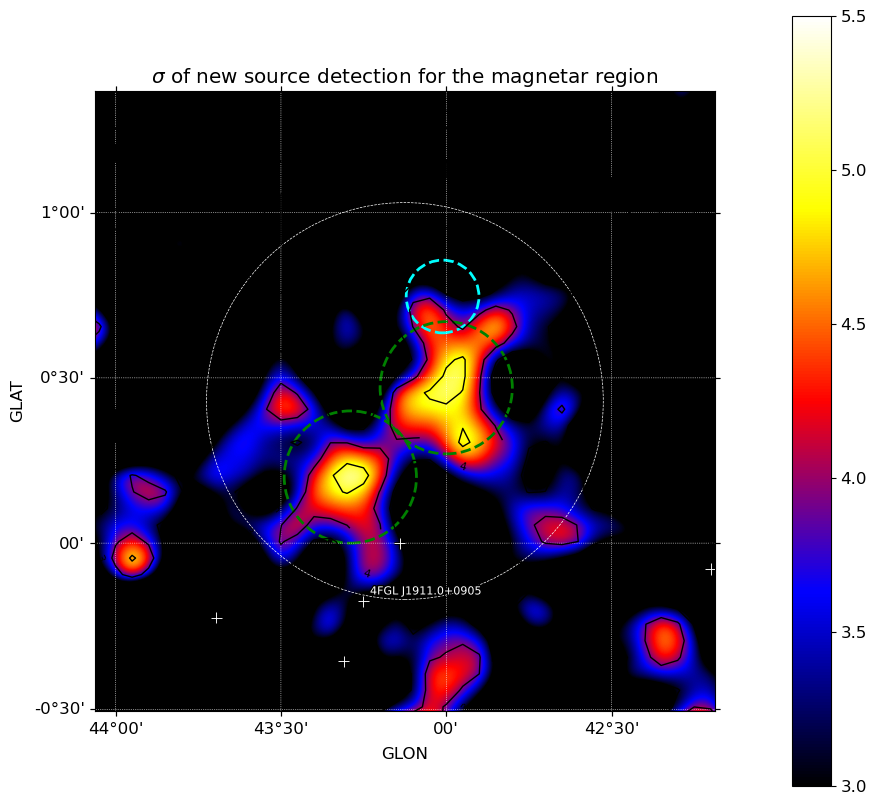

In [132]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5000.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation="bicubic", zoom=8,vmin=3,vmax=5.5, levels=[0,3,4,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')


glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

p.draw_circle(0.2,  # radius in degrees
              skydir=c1,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

p.draw_circle(0.2,  # radius in degrees
              skydir=c2,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sigma$ of new source detection for the magnetar region")
plt.show()

# Source split

## Two point like

In [117]:

glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

gta.delete_source('4FGL J1908.6+0915e') 
gta.delete_source('Src1_pointlike') 
gta.delete_source('Src2_pointlike') 
gta.delete_source('Src1_extended') 
gta.delete_source('Src2_extended') 

2025-05-15 12:16:29 ERROR   GTAnalysis.delete_source(): No source with name: 4FGL J1908.6+0915e
2025-05-15 12:16:29 INFO    GTAnalysis.delete_source(): Deleting source Src1_pointlike
2025-05-15 12:16:29 INFO    GTAnalysis.delete_source(): Deleting source Src2_pointlike
2025-05-15 12:16:29 INFO    GTAnalysis.delete_source(): Deleting source Src1_extended
2025-05-15 12:16:29 INFO    GTAnalysis.delete_source(): Deleting source Src2_extended


In [118]:
for i, coord in enumerate([c1,c2], start=1):
    gta.add_source(f"Src{i}_pointlike", {
        'type':         'PointSource',
        'glon':          coord.l.to_value(), 
        'glat':          coord.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })

2025-05-15 12:16:30 INFO    GTAnalysis.add_source(): Adding source Src1_pointlike
2025-05-15 12:16:32 INFO    GTAnalysis.add_source(): Adding source Src2_pointlike


In [119]:
gta.print_model()

2025-05-15 12:16:34 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_pointlike         0.131   1.000  3.56e-07   2.20       nan        40.7    *
Src1_pointlike         0.283   1.000  3.56e-07   2.20       nan        40.7    *
4FGL J1910.2+0904c     0.430   0.413  1.02e-05   2.51    285.96      1666.1    *
4FGL J1911.0+0905      0.619   0.707  5.61e-05   2.20   6522.96      7641.6    *
4FGL J1911.8+0903c     0.808   0.389  4.52e-06   2.49     51.55       728.0    *
4FGL J1912.0+0927      0.869   0.358  3.79e-06   3.00     96.01       875.1    *
4FGL J1908.7+0812      1.056   1.938  7.25e-06   3.36    318.30      1928.9    *
4FGL J1913.3+0905      1.183   0.871  7.37e-06   3.15    457.34      1566.3    *
4FGL J1912.7+0957      1.226   0.568  5.12e-06   3.03    186.22      1181.2    *
4FGL J1911.7+1014c     1.241   0.347  3.29e-06   3.25 

In [120]:
gta.optimize()
gta.fit()

2025-05-15 12:16:38 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 7952681.213
Fitting shape 4FGL J1907.9+0602 TS:  27973.029
Fitting shape 4FGL J1911.0+0905 TS:   6762.151
Fitting shape 4FGL J1906.4+0723 TS:   2162.605
Fitting shape 4FGL J1906.9+0712 TS:    640.438
Fitting shape 4FGL J1913.3+0905 TS:    454.255
Fitting shape 4FGL J1910.2+0904c TS:    344.679
Fitting shape 4FGL J1908.7+0812 TS:    333.061
Fitting shape 4FGL J1901.1+0730 TS:    242.511
Fitting shape 4FGL J1902.5+0654 TS:    227.081
Fitting shape 4FGL J1915.3+1149 TS:    224.392
Fitting shape 4FGL J1916.3+1108 TS:    191.800
Fitting shape 4FGL J1912.7+0957 TS:    187.840
Fitting shape 4FGL J1913.3+1019 TS:    183.339
Fitting shape 4FGL J1918.1+1215c TS:    177.112
Fitting shape 4FGL J1914.5+1107c TS:    149.741
Fitting shape 4FGL J1858.5+0640 TS:    134.783
Fitting shape 4FGL J1907.6+0703 TS:    127.520
Fitting shape 4FGL J1904.7+0615 TS:    101.048
Fitting shape 4FGL J1912.0+0927 TS:     96.098
Fitting shape 4FGL J1914.7+1012c TS:     87.115
Fitting shape 4FGL

2025-05-15 12:17:39 INFO    GTAnalysis.optimize(): Finished
2025-05-15 12:17:39 INFO    GTAnalysis.optimize(): LogLike: -1003431.185340 Delta-LogLike: 26.474816
2025-05-15 12:17:39 INFO    GTAnalysis.optimize(): Execution time: 60.67 s
2025-05-15 12:17:39 INFO    GTAnalysis.fit(): Starting fit.
2025-05-15 12:18:45 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-15 12:18:45 INFO    GTAnalysis.fit(): LogLike: -1003430.742 DeltaLogLike:        0.443 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.4429707097588107,
 'edm': 2.1189027265291184e-05,
 'loglike': -1003430.7423696993,
 'covariance': array([[ 1.83874477e-02,  8.09679988e-06,  1.00243097e-05,
          8.87295939e-05,  7.73417786e-06,  6.81658909e-06,
          6.68257741e-05,  6.76487769e-05,  5.00382659e-06,
          1.51188086e-06,  4.61062328e-05,  1.42129337e-05,
          9.15069092e-06,  9.72156627e-06,  1.16890963e-05,
          1.50263383e-05,  4.58679781e-06,  1.99615671e-05,
          6.69208038e-05,  1.91052611e-05,  1.77381890e-04,
          1.04685097e-03, -7.56591905e-06, -1.17963861e-12],
        [ 8.09679988e-06,  1.38730018e-03, -7.87169990e-05,
          9.95639681e-06, -1.11337886e-05,  2.27469496e-05,
          9.16677432e-06,  1.50124423e-05,  1.76466452e-06,
          5.45332799e-07,  1.73871980e-05,  5.42013709e-06,
          3.25750103e-06,  3.51616308e-06,  4.15075849e-06,
          5.33403643e-06,  1.61642167e-06,  7.13

In [121]:
gta.print_model()

2025-05-15 12:18:45 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_pointlike         0.131  22.182  2.26e-06   2.98     43.62       551.7    *
Src1_pointlike         0.283   5.689  2.02e-06   2.20     20.26       231.6    *
4FGL J1910.2+0904c     0.430   0.413  1.02e-05   2.50    283.83      1653.9    *
4FGL J1911.0+0905      0.619   0.707  5.61e-05   2.20   6545.02      7668.6    *
4FGL J1911.8+0903c     0.808   0.392   4.5e-06   2.48     50.61       715.2    *
4FGL J1912.0+0927      0.869   0.358  3.78e-06   3.00     95.71       871.5    *
4FGL J1908.7+0812      1.056   1.938  7.25e-06   3.36    318.22      1928.4    *
4FGL J1913.3+0905      1.183   0.872  7.38e-06   3.15    457.86      1567.9    *
4FGL J1912.7+0957      1.226   0.568  5.12e-06   3.03    186.32      1181.5    *
4FGL J1911.7+1014c     1.241   0.347  3.29e-06   3.25 

In [125]:
plt.clf()
plt.clf()
tsmap_postfit_with_2_point_sources = gta.tsmap(
    prefix='TSmap_2point_sources',
    make_plots=True,
    write_fits=True,
    write_npy=True,)

2025-05-15 12:21:25 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-15 12:21:29 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-15 12:23:23 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-15 12:23:25 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/TSmap_2point_sources_pointsource_powerlaw_2.00_tsmap.npy
2025-05-15 12:23:25 INFO    GTAnalysis.tsmap(): Execution time: 120.12 s


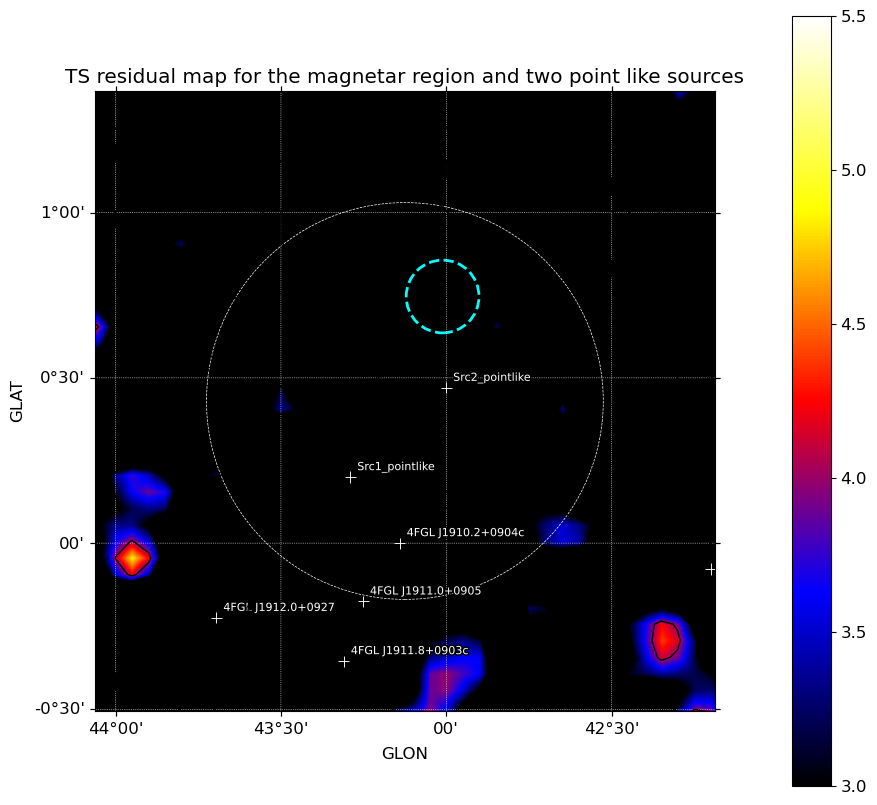

In [127]:
p = ROIPlotter(tsmap_postfit_with_2_point_sources['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation="bilinear", zoom=8,vmin=3,vmax=5.5, levels=[0,3,4,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')


glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

# p.draw_circle(0.05,  # radius in degrees
#               skydir=c1,
#               edgecolor='green',
#               linewidth=2.0,
#               linestyle='--')

# p.draw_circle(0.05,  # radius in degrees
#               skydir=c2,
#               edgecolor='green',
#               linewidth=2.0,
#               linestyle='--')

plt.title("TS residual map for the magnetar region and two point like sources")
plt.show()

## Two extended

In [86]:

glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

gta.delete_source('4FGL J1908.6+0915e')  # or gta.modify_source('old_disk', {'SpatialModel':'None'})
gta.delete_source('Src1_pointlike')  # or gta.modify_source('old_disk', {'SpatialModel':'None'})
gta.delete_source('Src2_pointlike')  # or gta.modify_source('old_disk', {'SpatialModel':'None'})

2025-05-14 18:26:16 ERROR   GTAnalysis.delete_source(): No source with name: 4FGL J1908.6+0915e
2025-05-14 18:26:16 INFO    GTAnalysis.delete_source(): Deleting source Src1_pointlike
2025-05-14 18:26:16 INFO    GTAnalysis.delete_source(): Deleting source Src2_pointlike


In [88]:
for i, coord in enumerate([c1,c2], start=1):
    gta.add_source(f"Src{i}_extended", {
        'type':         'RadialDisc',
        'radius':        0.1,
        'glon':          coord.l.to_value(), 
        'glat':          coord.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })

2025-05-14 18:26:46 INFO    GTAnalysis.add_source(): Adding source Src1_extended
2025-05-14 18:26:49 INFO    GTAnalysis.add_source(): Adding source Src2_extended


In [89]:
gta.optimize()
gta.fit()

2025-05-14 18:26:59 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 7952488.277
Fitting shape 4FGL J1907.9+0602 TS:  27973.360
Fitting shape 4FGL J1911.0+0905 TS:   6729.274
Fitting shape 4FGL J1906.4+0723 TS:   2163.331
Fitting shape 4FGL J1906.9+0712 TS:    640.076
Fitting shape 4FGL J1913.3+0905 TS:    453.770
Fitting shape 4FGL J1910.2+0904c TS:    348.671
Fitting shape 4FGL J1908.7+0812 TS:    332.893
Fitting shape 4FGL J1901.1+0730 TS:    242.529
Fitting shape 4FGL J1902.5+0654 TS:    227.094
Fitting shape 4FGL J1915.3+1149 TS:    224.427
Fitting shape 4FGL J1916.3+1108 TS:    191.811
Fitting shape 4FGL J1912.7+0957 TS:    187.723
Fitting shape 4FGL J1913.3+1019 TS:    183.324
Fitting shape 4FGL J1918.1+1215c TS:    177.153
Fitting shape 4FGL J1914.5+1107c TS:    149.762
Fitting shape 4FGL J1858.5+0640 TS:    134.782
Fitting shape 4FGL J1907.6+0703 TS:    127.703
Fitting shape 4FGL J1904.7+0615 TS:    101.076
Fitting shape 4FGL J1912.0+0927 TS:     96.271
Fitting shape 4FGL J1914.7+1012c TS:     87.099
Fitting shape 4FGL

2025-05-14 18:27:58 INFO    GTAnalysis.optimize(): Finished
2025-05-14 18:27:58 INFO    GTAnalysis.optimize(): LogLike: -1003431.267417 Delta-LogLike: 26.367460
2025-05-14 18:27:58 INFO    GTAnalysis.optimize(): Execution time: 58.96 s
2025-05-14 18:27:58 INFO    GTAnalysis.fit(): Starting fit.
2025-05-14 18:29:03 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-14 18:29:03 INFO    GTAnalysis.fit(): LogLike: -1003430.814 DeltaLogLike:        0.454 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.45382255245931447,
 'edm': 7.582847917281071e-06,
 'loglike': -1003430.8135944651,
 'covariance': array([[ 1.83925711e-02,  8.09696526e-06,  1.00195607e-05,
          8.86199190e-05,  7.72397183e-06,  6.46727664e-06,
          6.74330413e-05,  6.76181561e-05,  5.01697815e-06,
          1.48293841e-06,  4.61094891e-05,  1.42122137e-05,
          9.13807092e-06,  9.70109590e-06,  1.16852514e-05,
          1.49892050e-05,  4.58796404e-06,  1.99671925e-05,
          6.69259750e-05,  1.91125959e-05,  1.77122660e-04,
          1.04607621e-03, -7.56746064e-06, -6.12351175e-13],
        [ 8.09696526e-06,  1.38740335e-03, -7.86985230e-05,
          9.95477417e-06, -1.11360954e-05,  2.27519470e-05,
          9.15920709e-06,  1.50000906e-05,  1.76951066e-06,
          5.34725345e-07,  1.73861202e-05,  5.41918797e-06,
          3.25341605e-06,  3.50893477e-06,  4.14864609e-06,
          5.31988611e-06,  1.61661109e-06,  7.13

In [90]:
gta.print_model()

2025-05-14 18:30:55 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.131  22.168  2.26e-06   2.98     43.58       551.4    *
Src1_extended          0.283   5.684  2.02e-06   2.20     20.23       231.4    *
4FGL J1910.2+0904c     0.430   0.413  1.02e-05   2.51    285.96      1666.1    *
4FGL J1911.0+0905      0.619   0.707  5.61e-05   2.20   6522.96      7641.6    *
4FGL J1911.8+0903c     0.808   0.389  4.52e-06   2.49     51.55       728.0    *
4FGL J1912.0+0927      0.869   0.358  3.79e-06   3.00     96.01       875.1    *
4FGL J1908.7+0812      1.056   1.938  7.25e-06   3.36    318.30      1928.9    *
4FGL J1913.3+0905      1.183   0.871  7.37e-06   3.15    457.34      1566.3    *
4FGL J1912.7+0957      1.226   0.568  5.12e-06   3.03    186.22      1181.2    *
4FGL J1911.7+1014c     1.241   0.347  3.29e-06   3.25 

In [102]:
plt.clf()
plt.clf()
tsmap_postfit_2_extended = gta.tsmap(
    prefix='TSmap_2_extended',
    make_plots=True,
    write_fits=True,
    write_npy=True
    )

2025-05-14 20:17:56 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-14 20:18:01 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-14 20:19:44 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-14 20:19:47 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL/TSmap_2_extended_pointsource_powerlaw_2.00_tsmap.npy
2025-05-14 20:19:47 INFO    GTAnalysis.tsmap(): Execution time: 110.93 s


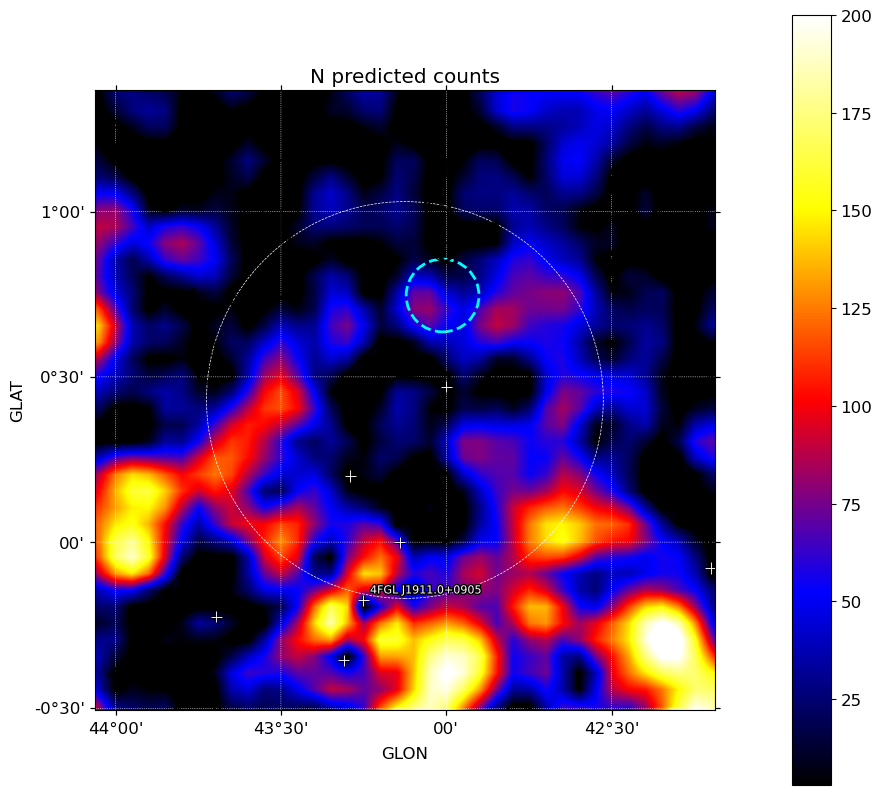

In [108]:
p = ROIPlotter(tsmap_postfit_2_extended['npred'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5000.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation="bilinear", zoom=8,vmin=3,vmax=200, levels=[0,3,4,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')


glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

# p.draw_circle(0.05,  # radius in degrees
#               skydir=c1,
#               edgecolor='green',
#               linewidth=2.0,
#               linestyle='--')

# p.draw_circle(0.05,  # radius in degrees
#               skydir=c2,
#               edgecolor='green',
#               linewidth=2.0,
#               linestyle='--')

plt.title("N predicted counts")
plt.show()

## 2 extended large circles

In [202]:
glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

gta.delete_source('4FGL J1908.6+0915e') 
gta.delete_source('Src1_pointlike') 
gta.delete_source('Src2_pointlike') 
gta.delete_source('Src1_extended') 
gta.delete_source('Src2_extended') 

2025-05-15 16:20:18 ERROR   GTAnalysis.delete_source(): No source with name: 4FGL J1908.6+0915e
2025-05-15 16:20:18 ERROR   GTAnalysis.delete_source(): No source with name: Src1_pointlike
2025-05-15 16:20:18 ERROR   GTAnalysis.delete_source(): No source with name: Src2_pointlike
2025-05-15 16:20:18 INFO    GTAnalysis.delete_source(): Deleting source Src1_extended
2025-05-15 16:20:18 INFO    GTAnalysis.delete_source(): Deleting source Src2_extended


In [203]:
for i, coord in enumerate([c1,c2], start=1):
    gta.add_source(f"Src{i}_extended", {
        'type':         'RadialDisc',
        'radius':        0.2,
        'glon':          coord.l.to_value(), 
        'glat':          coord.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })
gta.print_model()

2025-05-15 16:20:18 INFO    GTAnalysis.add_source(): Adding source Src1_extended
2025-05-15 16:20:23 INFO    GTAnalysis.add_source(): Adding source Src2_extended
2025-05-15 16:20:24 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.131   1.000  3.56e-07   2.20       nan        40.7    *
Src1_extended          0.283   1.000  3.56e-07   2.20       nan        40.7    *
4FGL J1910.2+0904c     0.430   0.422  1.04e-05   2.51    296.46      1705.0    *
4FGL J1911.0+0905      0.619   0.705   5.6e-05   2.20   6526.11      7673.1    *
4FGL J1911.8+0903c     0.808   0.396  4.51e-06   2.47     50.15       705.6    *
4FGL J1912.0+0927      0.869   0.358  3.78e-06   3.00     95.69       870.7    *
4FGL J1908.7+0812      1.056   1.940  7.26e-06   3.36    318.83      1930.3    *
4FGL J1913.3+0905      1.183   0.872  7.38e-06   3.15 

In [204]:
gta.optimize()
gta.fit()

2025-05-15 16:20:24 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 7952136.007
Fitting shape 4FGL J1907.9+0602 TS:  27974.637
Fitting shape 4FGL J1911.0+0905 TS:   6744.206
Fitting shape 4FGL J1906.4+0723 TS:   2162.114
Fitting shape 4FGL J1906.9+0712 TS:    640.715
Fitting shape 4FGL J1913.3+0905 TS:    456.094
Fitting shape 4FGL J1910.2+0904c TS:    345.663
Fitting shape 4FGL J1908.7+0812 TS:    332.282
Fitting shape 4FGL J1901.1+0730 TS:    242.604
Fitting shape 4FGL J1902.5+0654 TS:    227.164
Fitting shape 4FGL J1915.3+1149 TS:    224.477
Fitting shape 4FGL J1916.3+1108 TS:    191.918
Fitting shape 4FGL J1912.7+0957 TS:    188.052
Fitting shape 4FGL J1913.3+1019 TS:    183.336
Fitting shape 4FGL J1918.1+1215c TS:    177.233
Fitting shape 4FGL J1914.5+1107c TS:    149.786
Fitting shape 4FGL J1858.5+0640 TS:    134.845
Fitting shape 4FGL J1907.6+0703 TS:    127.488
Fitting shape 4FGL J1904.7+0615 TS:    101.191
Fitting shape 4FGL J1912.0+0927 TS:     96.193
Fitting shape 4FGL J1914.7+1012c TS:     87.121
Fitting shape 4FGL

2025-05-15 16:21:27 INFO    GTAnalysis.optimize(): Finished
2025-05-15 16:21:27 INFO    GTAnalysis.optimize(): LogLike: -1003431.197861 Delta-LogLike: 25.541722
2025-05-15 16:21:27 INFO    GTAnalysis.optimize(): Execution time: 62.38 s
2025-05-15 16:21:27 INFO    GTAnalysis.fit(): Starting fit.
2025-05-15 16:22:33 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-15 16:22:33 INFO    GTAnalysis.fit(): LogLike: -1003430.736 DeltaLogLike:        0.462 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.46151186351198703,
 'edm': 9.908775541882732e-07,
 'loglike': -1003430.7363491015,
 'covariance': array([[ 1.83858797e-02,  8.09572670e-06,  1.00216033e-05,
          8.86548076e-05,  7.73432815e-06,  6.81227931e-06,
          6.68246940e-05,  6.76319815e-05,  4.99591568e-06,
          1.52552143e-06,  4.61076681e-05,  1.42770059e-05,
          9.15112149e-06,  9.76592320e-06,  1.15667948e-05,
          1.50563587e-05,  4.60474809e-06,  1.99614383e-05,
          6.70059641e-05,  1.90949542e-05,  1.77403257e-04,
          1.04594813e-03, -7.56521100e-06, -3.74091950e-13],
        [ 8.09572670e-06,  1.38731612e-03, -7.87022341e-05,
          9.98563772e-06, -1.11349573e-05,  2.27445568e-05,
          9.15338580e-06,  1.50052288e-05,  1.76198677e-06,
          5.50322665e-07,  1.73886157e-05,  5.44347137e-06,
          3.25747406e-06,  3.53233755e-06,  4.10672910e-06,
          5.34524961e-06,  1.62303867e-06,  7.13

In [205]:
gta.print_model()

2025-05-15 16:22:33 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.131  22.147  2.26e-06   2.98     43.59       551.2    *
Src1_extended          0.283   5.690  2.02e-06   2.20     20.26       231.7    *
4FGL J1910.2+0904c     0.430   0.412  1.02e-05   2.50    283.01      1650.5    *
4FGL J1911.0+0905      0.619   0.706  5.61e-05   2.20   6554.61      7679.8    *
4FGL J1911.8+0903c     0.808   0.393  4.49e-06   2.47     50.07       707.6    *
4FGL J1912.0+0927      0.869   0.358  3.77e-06   3.00     95.57       871.0    *
4FGL J1908.7+0812      1.056   1.937  7.25e-06   3.36    318.18      1928.5    *
4FGL J1913.3+0905      1.183   0.872  7.38e-06   3.15    458.19      1570.4    *
4FGL J1912.7+0957      1.226   0.568  5.12e-06   3.03    186.30      1182.1    *
4FGL J1911.7+1014c     1.241   0.347  3.29e-06   3.25 

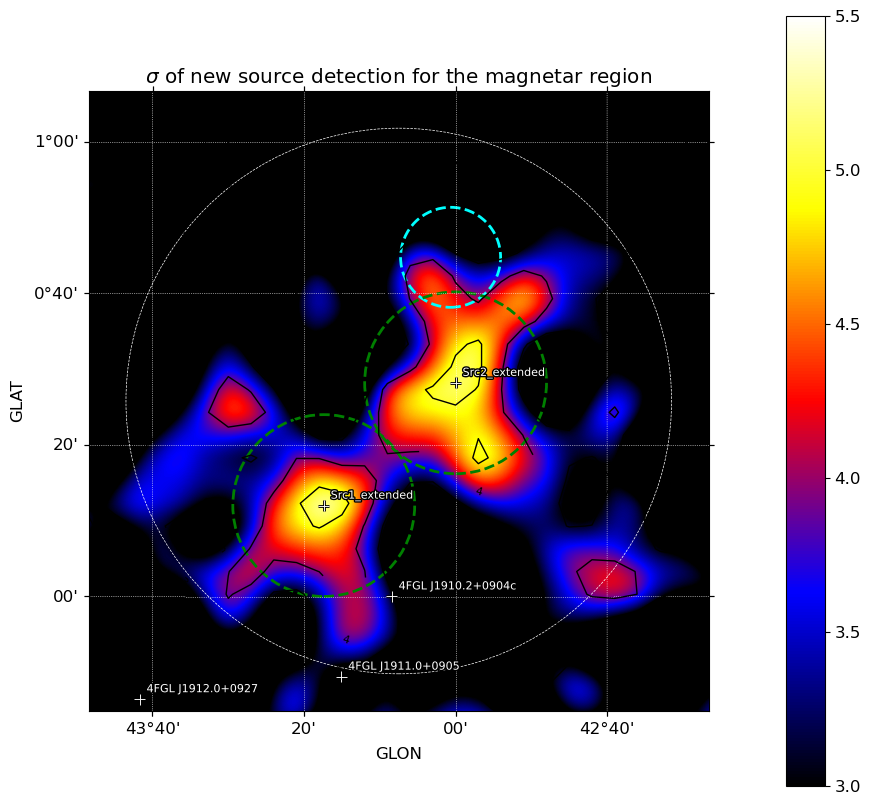

In [213]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=20.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation="bicubic", zoom=11,vmin=3,vmax=5.5, levels=[0,3,4,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')


glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

p.draw_circle(0.2,  # radius in degrees
              skydir=c1,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

p.draw_circle(0.2,  # radius in degrees
              skydir=c2,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sigma$ of new source detection for the magnetar region")
plt.show()

## 2 extended large circles, coincident with HESS

In [196]:

glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 42.95,  0.58  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

gta.delete_source('4FGL J1908.6+0915e') 
gta.delete_source('Src1_pointlike') 
gta.delete_source('Src2_pointlike') 
gta.delete_source('Src1_extended') 
gta.delete_source('Src2_extended') 

2025-05-15 16:18:03 ERROR   GTAnalysis.delete_source(): No source with name: 4FGL J1908.6+0915e
2025-05-15 16:18:03 ERROR   GTAnalysis.delete_source(): No source with name: Src1_pointlike
2025-05-15 16:18:03 ERROR   GTAnalysis.delete_source(): No source with name: Src2_pointlike
2025-05-15 16:18:03 INFO    GTAnalysis.delete_source(): Deleting source Src1_extended
2025-05-15 16:18:03 INFO    GTAnalysis.delete_source(): Deleting source Src2_extended


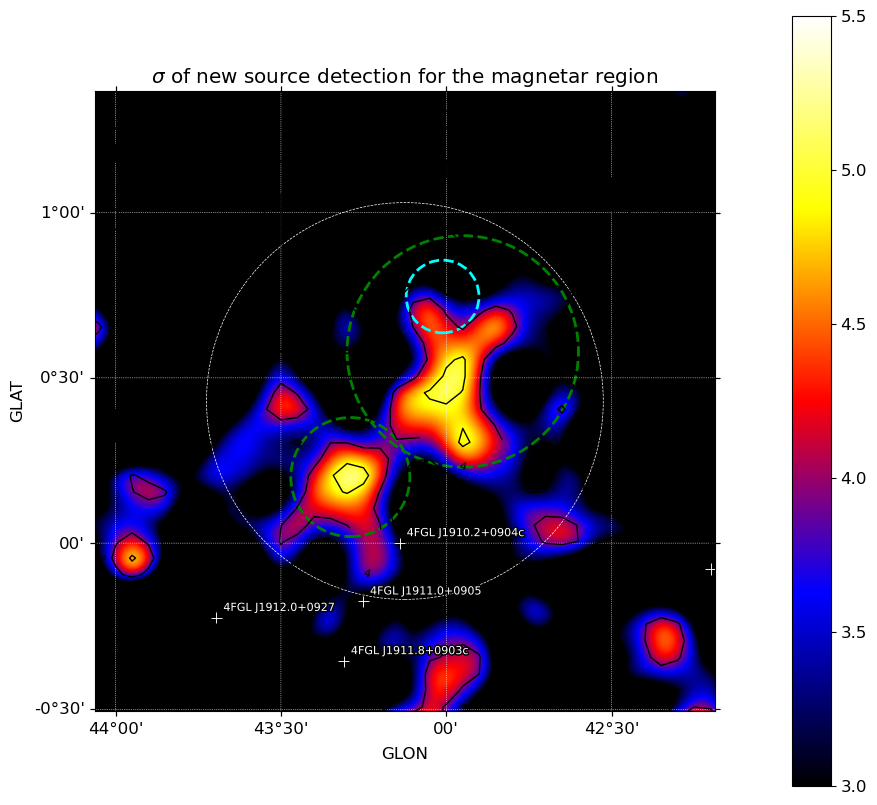

In [197]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=20.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation="bicubic", zoom=8,vmin=3,vmax=5.5, levels=[0,3,4,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

p.draw_circle(0.18,  # radius in degrees
              skydir=c1,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

p.draw_circle(0.35,  # radius in degrees
              skydir=c2,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sigma$ of new source detection for the magnetar region")
plt.show()

In [198]:
gta.add_source(f"Src1_extended", {
        'type':         'RadialDisc',
        'radius':        0.18,
        'glon':          c1.l.to_value(), 
        'glat':          c1.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })
gta.add_source(f"Src2_extended", {
        'type':         'RadialDisc',
        'radius':        0.35,
        'glon':          c2.l.to_value(), 
        'glat':          c2.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })

gta.print_model()

2025-05-15 16:18:04 INFO    GTAnalysis.add_source(): Adding source Src1_extended
2025-05-15 16:18:08 INFO    GTAnalysis.add_source(): Adding source Src2_extended
2025-05-15 16:18:10 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.230   1.000  3.56e-07   2.20       nan        40.9    *
Src1_extended          0.283   1.000  3.56e-07   2.20       nan        40.7    *
4FGL J1910.2+0904c     0.430   0.422  1.04e-05   2.51    297.20      1709.4    *
4FGL J1911.0+0905      0.619   0.705   5.6e-05   2.20   6519.41      7664.9    *
4FGL J1911.8+0903c     0.808   0.396  4.51e-06   2.47     50.40       708.9    *
4FGL J1912.0+0927      0.869   0.358  3.78e-06   3.00     95.77       871.2    *
4FGL J1908.7+0812      1.056   1.940  7.26e-06   3.36    318.87      1930.4    *
4FGL J1913.3+0905      1.183   0.872  7.38e-06   3.15 

In [199]:
gta.optimize()
gta.fit()

2025-05-15 16:18:10 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 7951205.784
Fitting shape 4FGL J1907.9+0602 TS:  27974.708
Fitting shape 4FGL J1911.0+0905 TS:   6738.904
Fitting shape 4FGL J1906.4+0723 TS:   2162.109
Fitting shape 4FGL J1906.9+0712 TS:    640.696
Fitting shape 4FGL J1913.3+0905 TS:    455.951
Fitting shape 4FGL J1910.2+0904c TS:    347.456
Fitting shape 4FGL J1908.7+0812 TS:    332.325
Fitting shape 4FGL J1901.1+0730 TS:    242.602
Fitting shape 4FGL J1902.5+0654 TS:    227.166
Fitting shape 4FGL J1915.3+1149 TS:    224.490
Fitting shape 4FGL J1916.3+1108 TS:    191.924
Fitting shape 4FGL J1912.7+0957 TS:    188.046
Fitting shape 4FGL J1913.3+1019 TS:    183.331
Fitting shape 4FGL J1918.1+1215c TS:    177.251
Fitting shape 4FGL J1914.5+1107c TS:    149.793
Fitting shape 4FGL J1858.5+0640 TS:    134.845
Fitting shape 4FGL J1907.6+0703 TS:    127.515
Fitting shape 4FGL J1904.7+0615 TS:    101.200
Fitting shape 4FGL J1912.0+0927 TS:     96.228
Fitting shape 4FGL J1914.7+1012c TS:     87.123
Fitting shape 4FGL

2025-05-15 16:19:11 INFO    GTAnalysis.optimize(): Finished
2025-05-15 16:19:11 INFO    GTAnalysis.optimize(): LogLike: -1003433.142482 Delta-LogLike: 23.378716
2025-05-15 16:19:11 INFO    GTAnalysis.optimize(): Execution time: 61.43 s
2025-05-15 16:19:11 INFO    GTAnalysis.fit(): Starting fit.
2025-05-15 16:20:18 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-15 16:20:18 INFO    GTAnalysis.fit(): LogLike: -1003432.923 DeltaLogLike:        0.219 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.21939649572595954,
 'edm': 4.487276999739362e-06,
 'loglike': -1003432.923085771,
 'covariance': array([[ 1.83800059e-02,  8.09739252e-06,  1.00232754e-05,
          8.86824113e-05,  7.73174405e-06,  6.81493720e-06,
          6.68485209e-05,  6.76981901e-05,  5.55398509e-06,
          1.46726084e-06,  4.61163690e-05,  1.42283771e-05,
          9.25158746e-06,  9.74719856e-06,  1.16879183e-05,
          1.50628800e-05,  4.58594736e-06,  1.99647096e-05,
          6.69291211e-05,  1.90981146e-05,  2.06738721e-04,
          9.73763080e-04, -7.56593505e-06, -1.34242735e-13],
        [ 8.09739252e-06,  1.38720436e-03, -7.86864533e-05,
          9.98138944e-06, -1.11344512e-05,  2.27311081e-05,
          9.16553868e-06,  1.50254518e-05,  1.96260831e-06,
          5.29357997e-07,  1.73951940e-05,  5.42627180e-06,
          3.29384020e-06,  3.52579554e-06,  4.15192609e-06,
          5.34901061e-06,  1.61672134e-06,  7.141

In [200]:
gta.print_model()

2025-05-15 16:20:18 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.230  19.586  2.03e-06   2.96     37.81       493.6    *
Src1_extended          0.283   6.177   2.2e-06   2.20     22.72       251.5    *
4FGL J1910.2+0904c     0.430   0.422  1.04e-05   2.51    296.46      1705.0    *
4FGL J1911.0+0905      0.619   0.705   5.6e-05   2.20   6526.11      7673.1    *
4FGL J1911.8+0903c     0.808   0.396  4.51e-06   2.47     50.15       705.6    *
4FGL J1912.0+0927      0.869   0.358  3.78e-06   3.00     95.69       870.7    *
4FGL J1908.7+0812      1.056   1.940  7.26e-06   3.36    318.83      1930.3    *
4FGL J1913.3+0905      1.183   0.872  7.38e-06   3.15    458.38      1570.1    *
4FGL J1912.7+0957      1.226   0.568  5.12e-06   3.03    186.42      1182.5    *
4FGL J1911.7+1014c     1.241   0.347   3.3e-06   3.25 

In [201]:
22**0.5

4.69041575982343